# Extending Computer Vision to Hidden Objects:
# A Tutorial on Millimeter-Wave Imaging and Reconstruction of Occluded Scenes

## 1) Setup

Install Requirements, import necessary files, and compile CUDA kernels

In [ ]:
!pip install connected-components-3d -q
!pip install open3d -q

### Only run the following cell if running the notebook locally

In [ ]:
# DO NOT RUN ON GOOGLE COLAB
# Only run this cell if running the notebook locally
# You may need to change your torch versions to match your system requirements
!pip install scikit-image 
!pip install matplotlib
!pip install torch==2.7.1 --index-url https://download.pytorch.org/whl/cu118
!pip install torchvision==0.22.1 --index-url https://download.pytorch.org/whl/cu118
!pip install scipy
!pip install numpy==1.24.3

# This will auto reload changes in src files
%load_ext autoreload
%autoreload 2

In [ ]:
# Imports
import torch
import numpy as np
import open3d as o3d
import plotly.graph_objects as go

from src.image_processor import ImageProcessor
from src.visualization import Visualizer
from src.sdf import compute_rsdf


device='cuda'

The following cell compiles two different CUDA kernels. It should automatically detect the CUDA versions and compile accordingly. 

In [ ]:
major, minor = torch.cuda.get_device_capability()
arch = f"{major}{minor}"

print("CUDA arch:", arch)
!nvcc --shared -Xcompiler -fPIC -arch sm_{major}{minor} --std=c++14 -o src/cuda/imaging_gpu_native_lib.so src/cuda/imaging_gpu_native_lib.cu;
!nvcc --shared -Xcompiler -fPIC -arch sm_{major}{minor} --std=c++14 -o src/cuda/surface_normal_est_native_lib.so src/cuda/surface_normal_est_native_lib.cu;

## 2) Process and Visualize a mmWave Image

The following cell defines the coordinates of the image to generate

In [ ]:
# Minimum and maximum image coordinate in each dimension
# These are defined to match the position of the object in the real-world
min_x =  0.07; max_x =  0.30
min_y =  0.20; max_y =  0.30
min_z = -0.47; max_z = -0.38

# Side length of each voxel. The processing code assumes all voxels are cubes
voxel_size = 0.0005 

# Define coordinates in each dimension
x_locs = np.arange(min_x, max_x, voxel_size)
y_locs = np.arange(min_y, max_y, voxel_size)
z_locs = np.arange(min_z, max_z, voxel_size)
image_coordinates = (torch.as_tensor(x_locs, dtype=torch.float32, device=device).contiguous(),
            torch.as_tensor(y_locs, dtype=torch.float32, device=device).contiguous(),
            torch.as_tensor(z_locs, dtype=torch.float32, device=device).contiguous())
            

Load the sample data.

There are two variables: 
- received_signals defines the signals received by the mmWave radar. It is of size (Num Antenna Locations, Num Samples, Num Receive Antennas)
- antenna_locations defines the location in 3D space where the radar was located when each measurement was taken. It is of size (Num Antenna Locations, 3)

In [ ]:
# Load data
data = np.load('data/sample_data.npz')
received_signals = torch.tensor(data['received_signals'])
antenna_locations = torch.tensor(data['antenna_locations'])
print(f'The shape of received_signals  is (Num Antenna Locations, Num Samples, Num Receive Antennas): {received_signals.shape}') 
print(f'The shape of antenna_locations is (Num Antenna Locations, 3): {antenna_locations.shape}') 

Next, we combine the received signals and antenna locations to produce an image at our defined image coordinates

In [ ]:
processor = ImageProcessor()
image = processor.generate_sar_image_simulation_gpu_native(received_signals, antenna_locations, image_coordinates)

Finally, we visualize the image. Since this is a 3D complex-valued image, we will plot the magnitude projected (by averaging) across one dimension. We will plot both the top view and side view. 

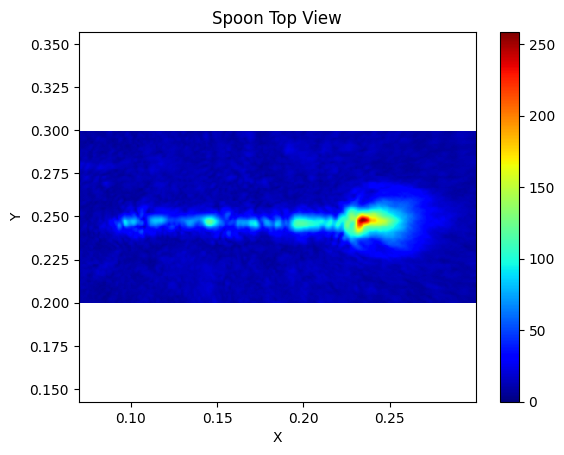

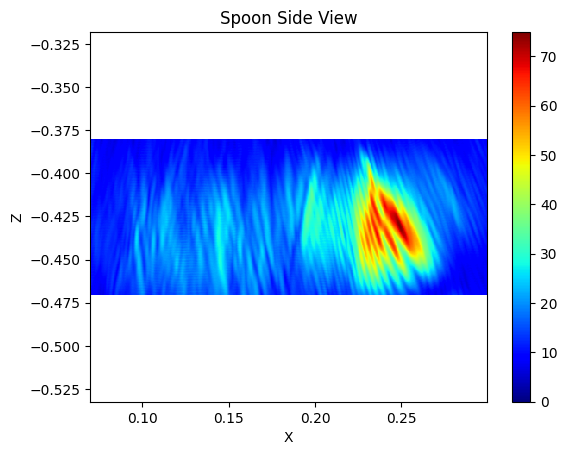

In [45]:
vis = Visualizer()
x_locs, y_locs, z_locs = image_coordinates
x_locs =  x_locs.cpu().numpy()
y_locs =  y_locs.cpu().numpy()
z_locs =  z_locs.cpu().numpy()

# You can change this value to clip the maximum power in the image. 
# For example, clip_power_percentage = 0.4 would clip all power above 40% of the maximum power in the image
clip_power_percentage = 1.0

vis.plot_sar_image(image.cpu().numpy(), x_locs, y_locs, z_locs, plot_dim=2, normalization=clip_power_percentage, plot_all_slices=False, title='Spoon Top View')
vis.plot_sar_image(image.cpu().numpy(), x_locs, y_locs, z_locs, plot_dim=1, normalization=clip_power_percentage, plot_all_slices=False, title='Spoon Side View')


## 3) Estimate Surface Normals and Perform 3D Reconstruction

In [ ]:
normals = processor.generate_mmwave_surface_normals_gpu_native(received_signals, antenna_locations, image_coordinates, image)

In [ ]:
image = image.to(dtype=torch.complex128)
sdf = compute_rsdf(image.cpu().numpy(), x_locs, y_locs, z_locs, antenna_locations.cpu().numpy(), normals.cpu().numpy())

In [ ]:
# Define 3D coordinate grid
mesh1, mesh2, mesh3 = np.meshgrid(y_locs, x_locs, z_locs)
coords_full = np.concatenate((mesh2[...,np.newaxis], mesh1[...,np.newaxis],mesh3[...,np.newaxis]), axis=-1) # Define full numpy array of coordinates of every voxel

# Select the desired isosurface
# Currently hard coded to fixed isosurface. This does not perform mmNorm's isosurface optimization (due to time constraints)
# Please see full research code (https://github.com/signalkinetics/mmNorm) for isosurface optimization code
tau = 0.0 
selected_idx = np.abs(sdf-tau) < 0.0005
points = coords_full[selected_idx]

In [ ]:
# Visualize the final reconstruction
fig = go.Figure(data=[go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2],
                mode="markers", marker=dict(size=3, opacity=0.8))])
fig.update_layout(scene=dict(aspectmode="data"))
fig.show()